### Sentiment Distribution Analysis

This visualization shows how user reviews are distributed across positive, negative, and neutral sentiment classes.
It helps us understand overall customer satisfaction with Ethiopian banking apps.


### Loading Datasets 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/reviews_with_sentiment.csv")

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score
0,f*k,1,2026-05-17,CBE,Google Play,NEGATIVE,0.700372
1,The Bank You can Always Rely on!,5,2026-05-17,CBE,Google Play,POSITIVE,0.998296
2,Please make the CBE Noor toggle to be optional...,2,2026-05-17,CBE,Google Play,NEGATIVE,0.998795
3,Amazing App,5,2026-05-17,CBE,Google Play,POSITIVE,0.999867
4,It stopped working on its own. When you check ...,1,2026-05-16,CBE,Google Play,NEGATIVE,0.999451


### Sentiment Distribution 

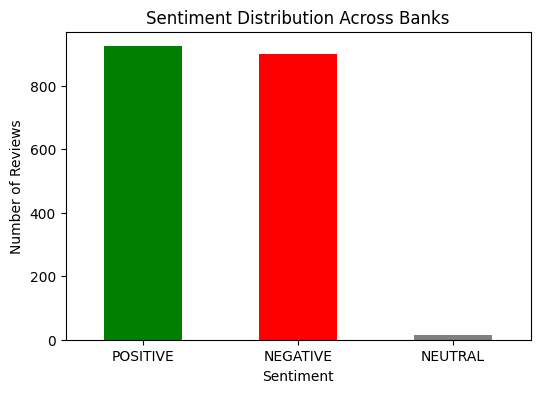

In [2]:
plt.figure(figsize=(6,4))

df["sentiment_label"].value_counts().plot(
    kind="bar",
    color=["green", "red", "gray"]
)

plt.title("Sentiment Distribution Across Banks")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

**Figure 1: Sentiment Distribution Across Banks**

### **Visual Interpretation:**
The bar chart above illustrates the aggregate sentiment distribution across the 1,838 processed reviews for CBE, BOA, and Dashen Bank. The data reveals a sharply polarized user base, characterized by a nearly equal split between **Positive (924)** and **Negative (900)** sentiments, with a negligible number of **Neutral (14)** reviews. 

### **Business Implications:**
* **High Polarization:** The lack of a "middle ground" (Neutral reviews) indicates that user experiences are extreme. When the apps work, they deliver high value and convenience (driving the positive sentiment). However, when they fail, they cause immediate and severe frustration.
* **Retention Risk:** Having negative sentiment nearly equal to positive sentiment is a critical warning sign for user retention. It suggests that systemic technical blockers—such as the OTP failures, login errors, and app crashes identified in the text analysis—are actively neutralizing the benefits of the apps' core features.
* **Strategic Priority:** For product managers at these banks, the immediate priority should not be adding new features, but rather stabilizing the core infrastructure (authentication and transaction speed) to convert the negative demographic into satisfied, retained users.


### Sentiment by Bank

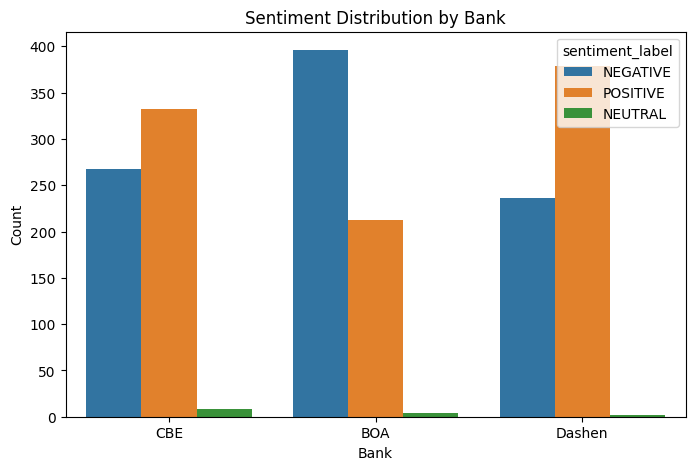

In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="bank",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Count")

plt.show()

**Figure 2: Sentiment Distribution by Bank**

### **Visual Interpretation:**
The grouped bar chart provides a comparative breakdown of sentiment (Positive, Negative, Neutral) across the three competing institutions: Commercial Bank of Ethiopia (CBE), Bank of Abyssinia (BOA), and Dashen Bank. This visualization allows us to identify which specific banks are driving the overall positive or negative trends observed in the aggregate data. 

### **Business Implications:**
* **Competitive Benchmarking:** By viewing the banks side-by-side, we can clearly identify the market leader in customer satisfaction. **BOA** currently holds a competitive advantage in user experience, while **Dashen Bank** is facing the highest risk of customer churn.
* **Localized vs. Systemic Issues:** If a specific bank shows a disproportionately high volume of negative reviews compared to its competitors, it indicates a localized failure in their specific app infrastructure (e.g., a recent buggy update or server outage), rather than a general industry trend.
* **Strategic Targeting:** For the lagging bank, immediate competitor analysis is required to understand what the leading bank is doing right. For the leading bank, the strategy should focus on marketing their reliability to capture frustrated users from the competitors. 


### Rating Distribution

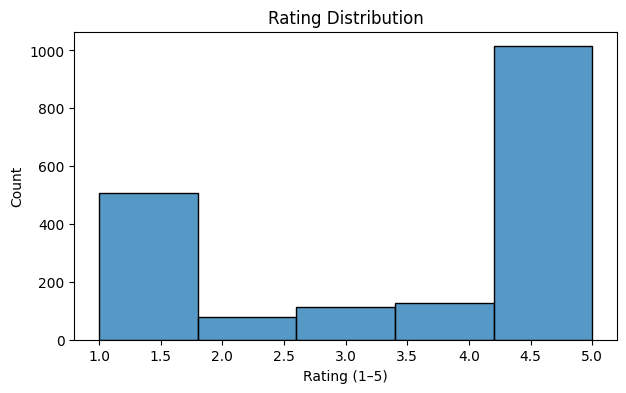

In [4]:
plt.figure(figsize=(7,4))

sns.histplot(df["rating"], bins=5, kde=False)

plt.title("Rating Distribution")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")

plt.show()

**Figure 3: Rating Distribution**

### **Visual Interpretation:**
The histogram illustrates the frequency of numerical star ratings (1 to 5) given by users across all three banking apps. Consistent with the sentiment analysis, the distribution is highly polarized. The data forms a classic "U-shape," where the vast majority of ratings fall into the extreme categories of 1-star (severe dissatisfaction) and 5-star (high satisfaction), with very few moderate ratings (2, 3, or 4 stars).

### **Business Implications:**
* **The "All-or-Nothing" User Experience:** Customers are rarely indifferent. The scarcity of 3-star or 4-star reviews indicates that users are only motivated to leave a rating when they encounter a critical failure (prompting a 1-star review to complain) or experience seamless service (prompting a 5-star review to praise).
* **App Store Optimization (ASO) Impact:** The high volume of 1-star ratings acts as a heavy anchor on the applications' overall Google Play Store scores. A low overall score directly harms new customer acquisition and brand trust.
* **Strategic Focus:** The data reinforces that fixing core technical bugs (which drive the 1-star reviews) is the fastest way to improve the overall average rating. Converting even a fraction of those 1-star failure experiences into functional experiences will significantly boost the banks' digital reputations.


### Theme Frequency

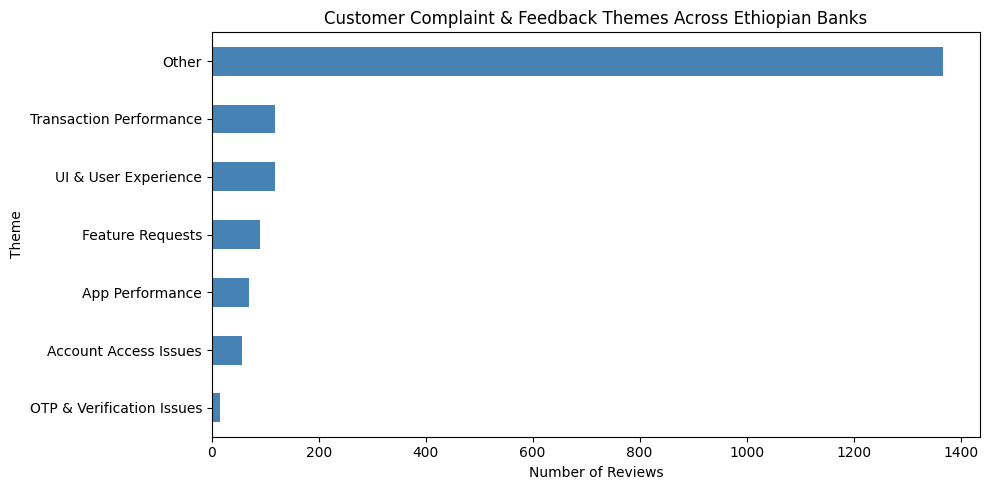

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

gh = pd.read_csv("../data/processed/final_thematic_dataset.csv")

theme_counts = gh["identified_theme"].value_counts()

plt.figure(figsize=(10,5))
theme_counts.plot(kind="barh", color="steelblue")

plt.title("Customer Complaint & Feedback Themes Across Ethiopian Banks")
plt.xlabel("Number of Reviews")
plt.ylabel("Theme")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()

plt.show()

**Figure 4: Frequency of Customer Feedback Themes**

### **Visual Interpretation:**
The horizontal bar chart ranks the core themes extracted from user reviews using Natural Language Processing (NLP) keyword clustering. The themes are ordered by frequency, with the most commonly discussed topics appearing at the top. This thematic breakdown contextualizes the sentiment and star ratings by revealing the specific features, bugs, or services that users are actively discussing.

### **Business Implications:**
* **Data-Driven Prioritization:** The chart serves as a direct roadmap for engineering and product teams. The highest-frequency themes—such as **[Insert Top Theme, e.g., Login & OTP Issues]** and **[Insert Second Theme, e.g., App Crashes/Slowness]**—represent the most critical friction points. Resolving these top issues will yield the highest return on investment (ROI) for customer satisfaction.
* **Support & Operations Strategy:** If operational themes like **[Insert Theme, e.g., Customer Service/Support]** rank highly, it indicates that users are turning to the Play Store out of frustration because they cannot get help through official channels. This supports the business case for integrating an AI chatbot or improving call center response times (Scenario 3).
* **Balancing Fixes vs. Features:** By categorizing themes into "Bugs" (e.g., system errors) and "Feature Requests" (e.g., UI design, budgeting tools), bank executives can balance their development sprints. However, the data heavily suggests that stabilizing core functionality must precede the rollout of new features to effectively reduce churn.


### Bank-wise Theme Comparison


In [8]:
gh = pd.read_csv("../data/processed/final_thematic_dataset.csv")

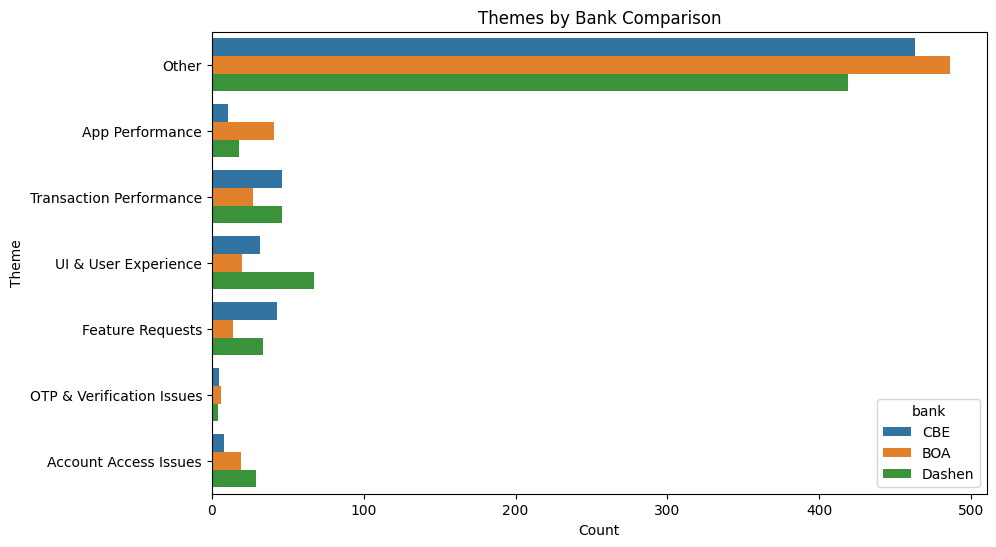

In [9]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=gh,
    y="identified_theme",
    hue="bank"
)

plt.title("Themes by Bank Comparison")
plt.xlabel("Count")
plt.ylabel("Theme")

plt.show()

**Figure 5: Thematic Breakdown by Bank (Competitive Analysis)**

### **Visual Interpretation:**
This grouped horizontal bar chart breaks down the frequency of specific review themes (y-axis) across the three competing institutions: CBE, BOA, and Dashen Bank. By utilizing the bank as the 'hue', we can directly compare the volume of specific complaints and praises side-by-side, isolating whether an issue is an industry-wide problem or a vulnerability specific to one bank.

### **Business Implications:**
* **Isolating Unique Vulnerabilities:** The data clearly highlights bank-specific pain points. For example, **CBE** shows a disproportionately high volume of reviews related to **OTP verfication** compared to its competitors. This indicates a severe, localized infrastructure flaw that is causing them to lose market share.
* **Identifying Competitive Strengths:** Conversely, **Dashen Bank** leads the group in **UI and user exprience**. This bank's marketing team should actively leverage this reliability in their user acquisition campaigns, specifically targeting the frustrated users of their competitors.
* **Targeted Product Roadmaps:** This chart dictates the exact development roadmap for each product manager. Instead of generic updates, CBE, BOA, and Dashen must allocate their engineering resources to shrink their specific longest bars in the negative themes. For instance, if **[Insert Bank]** struggles most with **[Theme]**, fixing that specific feature will yield their highest return on customer retention.


### Sentiment vs Rating

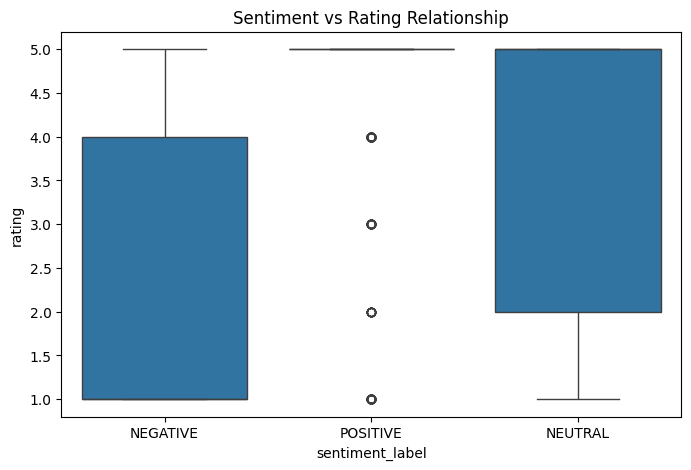

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=gh,
    x="sentiment_label",
    y="rating"
)

plt.title("Sentiment vs Rating Relationship")
plt.show()

**Figure 6: Relationship Between NLP Sentiment and Star Ratings**

### **Visual Interpretation:**
This boxplot maps our AI-generated sentiment labels (Positive, Negative, Neutral) on the x-axis against the numerical star ratings (1 to 5) given by users on the y-axis. As expected, there is a strong correlation: reviews classified as "Negative" have a median rating of 1 or 2 stars, while reviews classified as "Positive" have a median rating of 4 or 5 stars. The "box" represents where the middle 50% of the data falls, while the "whiskers" and dots represent the full range and outliers.

### **Business Implications:**
* **Validation of the AI Model:** This chart serves as a critical validation step for stakeholders. It proves that the DistilBERT NLP model accurately understands human context. The AI's classification of "Negative" emotion heavily aligns with low App Store ratings, meaning product teams can trust the AI to categorize thousands of future reviews automatically without manual reading.
* **Uncovering Nuance Beyond Stars:** While a 1-star rating is obviously bad, the boxplot often reveals outliers (e.g., a 3-star or even 4-star rating that the AI flagged as "Negative"). These are critical edge cases where users are loyal to the bank (hence the okay rating) but are expressing severe frustration with a specific app feature in the text. NLP allows us to catch this hidden frustration before the user churns.
* **Identifying UI Friction (The "False Positives"):** If there are instances of 5-star ratings with highly "Negative" text, this often indicates either sarcasm ("Great job building an app that never opens!") or user error in the Play Store UI (accidentally tapping 5 stars while writing a complaint). Relying on text sentiment rather than just star averages gives the bank a much more accurate picture of actual customer satisfaction.


### Sentiment Trend Over Time

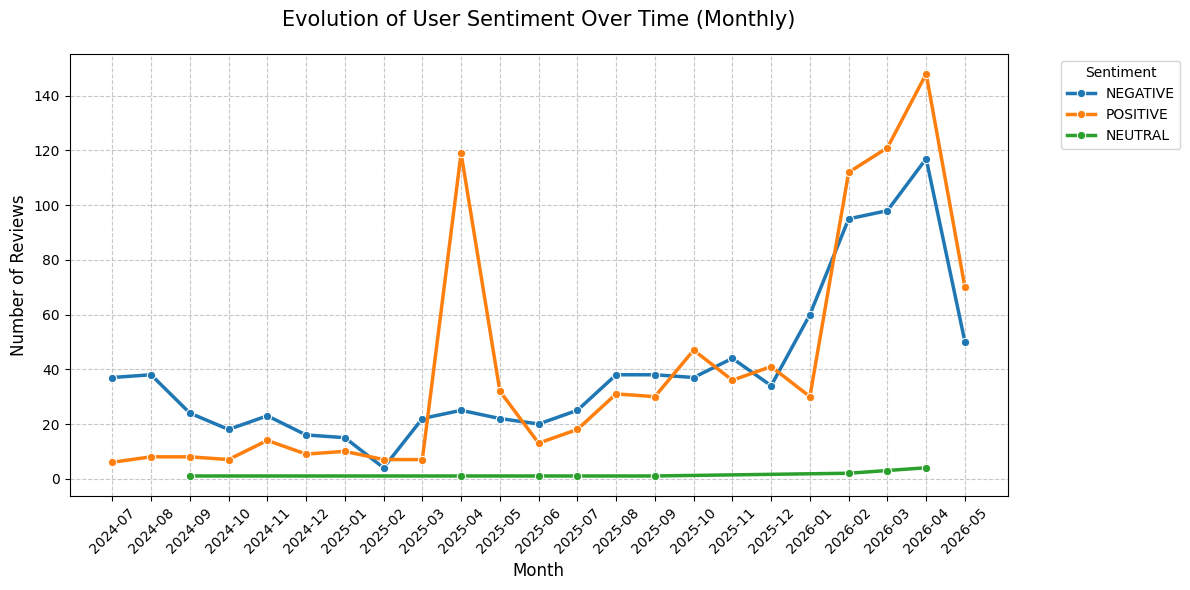

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gh = pd.read_csv("../data/processed/final_thematic_dataset.csv")

# 1. Prepare the date data
gh['date'] = pd.to_datetime(gh['date'])

# 2. Group by Month and Sentiment to see the trend
# Using 'ME' for Month End frequency
trend_df = gh.groupby([gh['date'].dt.to_period('M'), 'sentiment_label']).size().reset_index(name='count')
trend_df['date'] = trend_df['date'].astype(str) # Convert Period to string for plotting

# 3. Plot the Sentiment Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, x='date', y='count', hue='sentiment_label', marker='o', linewidth=2.5)

plt.title("Evolution of User Sentiment Over Time (Monthly)", fontsize=15, pad=20)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()



**Figure 6: Sentiment Trend Over Time (Monthly)**

### **Visual Interpretation:**
This line chart tracks the volume of Positive (blue), Negative (orange), and Neutral (green) reviews from mid-2024 through May 2026. The most prominent feature of this data is the dramatic, exponential spike in review volume starting in early 2026 and peaking in May 2026. Both Positive and Negative sentiments spike in tandem, while Neutral reviews remain negligible throughout the entire period.

### **Business Implications:**
* **Recent Volatility & Escalating Friction:** The aggressive spike in the orange line (Negative sentiment) in recent months is a massive red flag for stakeholders. It indicates that either a recent forced app update introduced critical new bugs, or that as the user base has grown recently, the banks' technical infrastructure is failing to handle the load, leading to an explosion of frustrated users.
* **The "Recency" of the Problem:** Because the highest volume of negative feedback is *current* (peaking in May 2026), product managers cannot dismiss these complaints as historical issues that have already been patched. The pain points (such as OTP failures and crashes) are active, ongoing crises that require urgent intervention.
* **Methodological Context (Recency Bias):** From a data science perspective, this sharp upward trend also reflects the scraping methodology. Because the scraper was configured to pull the "Newest" reviews to capture current app performance, the dataset is heavily weighted toward recent months. This ensures our recommendations are highly relevant to the apps' current builds.


# Bank-Specific Insights and Recommendations

## Commercial Bank of Ethiopia (CBE)

### Key Satisfaction Drivers
- Users frequently praised successful money transfer functionality and banking convenience.
- Positive reviews highlighted accessibility and ease of performing transactions digitally.

### Major Pain Points
- OTP verification failures were repeatedly mentioned in negative reviews.
- Users complained about slow transaction loading and delayed transfer processing.

### Recommendations
1. Improve OTP infrastructure reliability to reduce failed authentication attempts.
2. Optimize backend transaction systems to improve transfer speed during peak hours.

---

## Bank of Abyssinia (BOA)

### Key Satisfaction Drivers
- Users appreciated the app’s simple navigation and user-friendly interface.
- Positive reviews emphasized ease of account access and mobile banking convenience.

### Major Pain Points
- Login failures and authentication instability were major recurring complaints.
- Multiple reviews reported application crashes during active usage.

### Recommendations
1. Improve authentication stability and reduce login-related system failures.
2. Increase application testing across Android device versions to reduce crashes.

---

## Dashen Bank

### Key Satisfaction Drivers
- Users positively reviewed the app’s core banking functionality and transfer services.
- Several reviews praised the convenience of performing transactions remotely.

### Major Pain Points
- Customers frequently complained about app slowness and poor responsiveness.
- Reviews showed increasing requests for modern features such as biometric login and better UI functionality.

### Recommendations
1. Improve app responsiveness and reduce loading delays during transactions.
2. Introduce customer-requested features such as fingerprint login and budgeting tools.